### Multiclass classification, One-vs-All, All-vs-All Method, SoftMax, Cross-Entropy, Multiclass Metrics - Accuracy, Precision, Recall - Micro and Macro -averaging

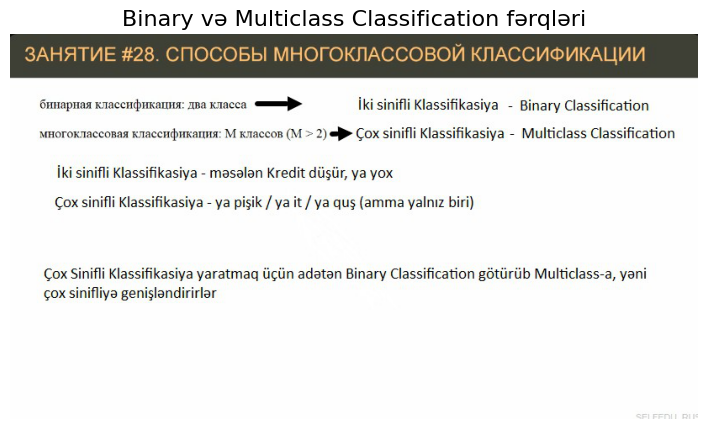

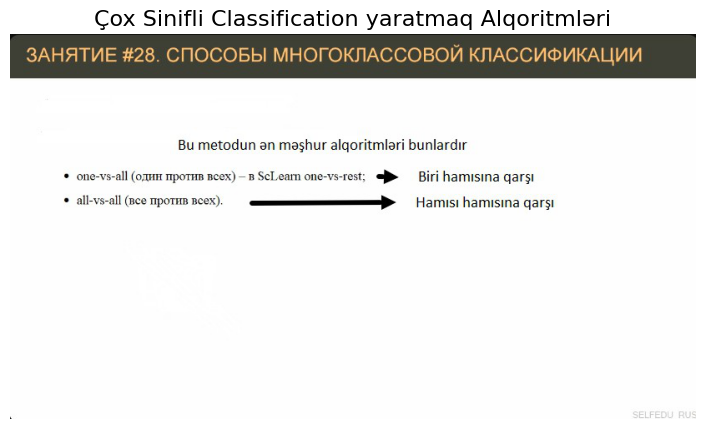

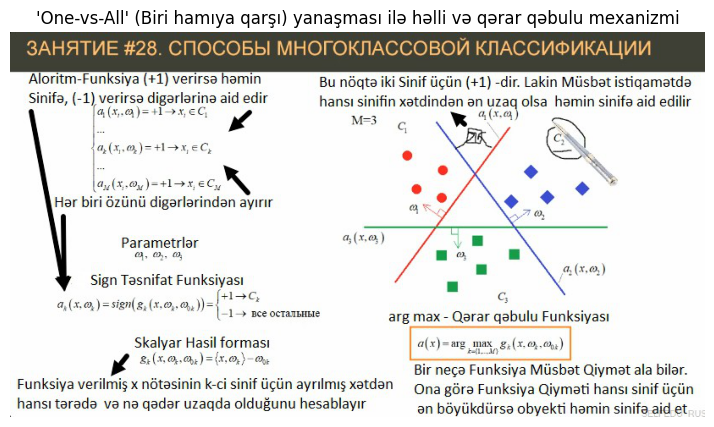

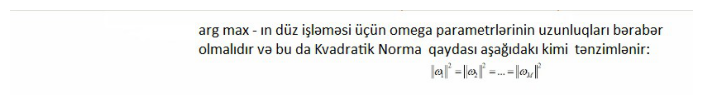

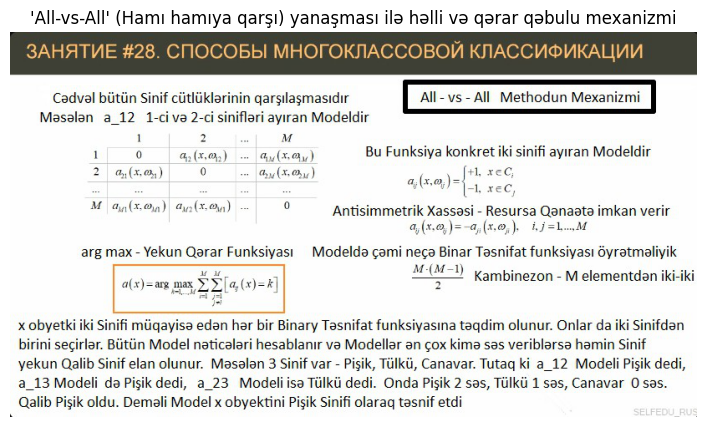

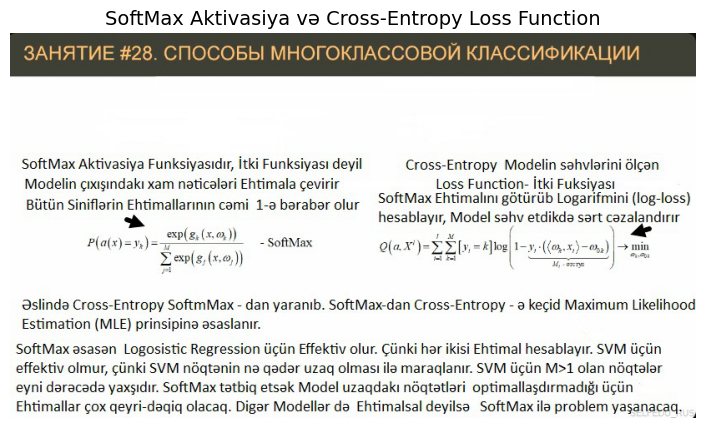

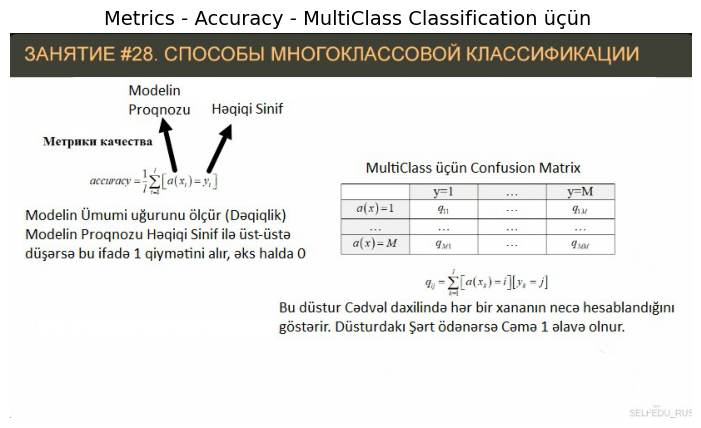

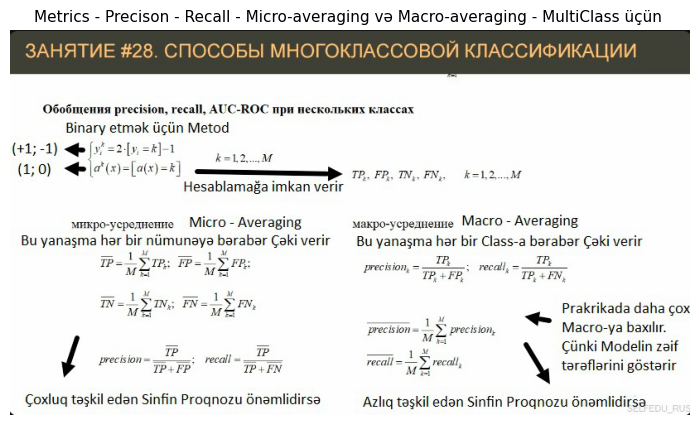

In [3]:
from PIL import Image

# Fayl yolunun əsas hissəsi
base_path = r'C:\Users\dell\Desktop\Selfedu\Pictures\ML_28_'

# Şəkilləri saxlayacağımız siyahı
image_list = []

# 1-dən 5-ə qədər olan şəkilləri dövr ilə açırıq
for i in range(1, 9):  # 1-dən 5-ə qədər
    full_path = f'{base_path}{i}.jpg'  # Fayl yolunu dinamik olaraq yaradırıq
    img = Image.open(full_path)
    image_list.append(img)  # Şəkili siyahıya əlavə edirik

# Nəticə: images siyahısında bütün yüklənmiş şəkillər olacaq

import matplotlib.pyplot as plt

# Şəkilləri göstərin
for i, image in enumerate(image_list):
    if i == 3:
        plt.figure(figsize=(8.8, 4))          
    else:     
        plt.figure(figsize=(25, 5))  # Şəkilin ölçüsü    
        
    if i < 1:
        plt.title("""Binary və Multiclass Classification fərqləri""", size='16')
    elif i < 2:
        plt.title("""Çox Sinifli Classification yaratmaq Alqoritmləri""", size='16')
    elif i < 3:
        plt.title("""'One-vs-All' (Biri hamıya qarşı) yanaşması ilə həlli və qərar qəbulu mexanizmi""", size='12')
    elif i < 4:
        plt.title("""""", size='12')
    elif i < 5:
        plt.title("""'All-vs-All' (Hamı hamıya qarşı) yanaşması ilə həlli və qərar qəbulu mexanizmi""", size='12')
    elif i < 6:
        plt.title("""SoftMax Aktivasiya və Cross-Entropy Loss Function""", size='14')
    elif i < 7:
        plt.title("""Metrics - Accuracy - MultiClass Classification üçün """, size='14')
    elif i < 8:
        plt.title("""Metrics - Precison - Recall - Micro-averaging və Macro-averaging - MultiClass üçün """, size='11')         

    plt.imshow(image)
    plt.axis('off')  # Oxları gizlətmək üçün
    plt.show()

### **Multiclass Classification**

> **Maşın öyrənməsində təsnifat (classification) obyektləri müəyyən əlamətlərinə görə müvafiq kateqoriyalara (siniflərə) bölmək prosesidir. Bu proses siniflərin sayından asılı olaraq iki əsas qrupa bölünür: Binary (İkili) və Multi-class (Çoxsinifli).**

<br>

#### **1. Binar (İkili) Təsnifat**
- **Bu, təsnifatın ən sadə formasıdır. Burada yalnız iki mümkün sinif mövcuddur. Model verilən obyekt üçün "bu, yoxsa o?" sualına cavab axtarır:**

    * **Məntiq:** **Giriş məlumatı ($x$) iki etiketdən ($y \in \{0, 1\}$) birinə aid edilir.**
    * **Həndəsi təsviri:** **İkiölçülü fəzada bu, adətən sinifləri ayıran tək bir düz xətt (və ya hipermüstəvi) deməkdir.**
    * **Nümunə:** 
        - **E-poçtun spam olub-olmaması; 
        - **Tibbi testin pozitiv və ya neqativ çıxması.**
        - **Bir meyvə verilir və sən yalnız onun "alma" olub-olmadığını deməlisən. Cavab ya "Hə" (1), ya da "Yox" (0) ola bilər.**

<br>

#### **2. Multi-class (Çoxsinifli) Təsnifat**
- **Əgər həll edilməli olan məsələdə siniflərin sayı 2-dən çoxdursa ($M > 2$), bu çoxsinifli təsnifat adlanır. Burada hər bir obyekt yalnız bir sinfə aid edilə bilər:**

    * **Məntiq:** **Model obyekti bir çox mümkün kateqoriya arasından ən uyğun olanına yerləşdirir.**
    * **Həndəsi təsviri:** **Fəza bir neçə müxtəlif nahiyəyə bölünür və hər bir nahiyə konkret bir sinfi təmsil edir.**
    * **Nümunə:** 
        - **Əl yazısı rəqəmlərinin (0, 1, 2...9) tanınması;**
        - **Şəkillərdəki heyvan növlərinin (it, pişik, quş) təyini.**
        - **Bir səbət meyvə var: alma, armud, banan. Sən meyvəni götürüb bu üç qutudan birinə qoymalısan. Obyekt mütləq yalnız bir sinfə aid olmalıdır.**

- **Fərq:** 
> **Binar təsnifatda biz "alma yoxsa alma deyil?" deyirdik. Çoxsiniflidə isə "alma, armud, yoxsa banan?" deyirik.**

<br>

#### **Aralarındakı Əsas Fərqlər**

| Xüsusiyyət | Binar Təsnifat | Multi-class Təsnifat |
| :--- | :--- | :--- |
| **Sinif Sayı** | **Cəmi 2 ($y=0$ və ya $y=1$)** | **2-dən çox** ($y \in \{1, 2, \dots, M\}$) |
| **Qərar Sərhədi** | **Tək bir ayırıcı sərhəd bəs edir** | **Mürəkkəb və çoxsaylı sərhədlər tələb olunur** |
| **Çıxış Ehtimalı** | **Tək bir ehtimal (məsələn, 0.7) kifayətdir** | **Hər bir sinif üçün ayrı ehtimal paylanması (Softmax)** |

<br>

#### **Çoxsinifli Təsnifatın Reallaşdırılması**
- **Bəzi alqoritmlər (məsələn, Qərar Ağacları və ya Neyron Şəbəkələri) təbii olaraq çoxsinifli datalarla işləyə bilir. Lakin xətti modellər (SVM, Logistic Regression) əslində binar təsnifat üçün yaradılıb. Onları çoxsinifli etmək üçün iki əsas yanaşma tətbiq olunur:**

    - **One-vs-All (OvA): Hər bir sinif üçün bir model qurulur. Hər model bir sinfi "digər hamısına" qarşı ayırmağı öyrənir. Sonda ən yüksək xal verən model qalib gəlir.**
        - **One-vs-All (Biri hamıya qarşı)**
            - **Modeli hər sinif üçün ayrıca öyrədirik:**
                - **1.  Model 1: Alma vs (Armud + Banan) $\to$ "Bu almadır?"**
                - **2.  Model 2: Armud vs (Alma + Banan) $\to$ "Bu armuddur?"**
                - **3.  Model 3: Banan vs (Alma + Armud) $\to$ "Bu banandır?"**
                
                <br>
                
                - **Qərar: Hansı model daha "əminliklə" (yüksək balla) "Hə" deyirsə, qalib odur.**
    
    <br>

    - **All-vs-All (AvA): Hər iki sinif cütlüyü üçün ayrı-ayrı modellər qurulur. Məsələn, 3 sinif varsa: (1 vs 2), (1 vs 3) və (2 vs 3). Sonda ən çox "səs" toplayan sinif seçilir.**
        - **All-vs-All (Hamı hamıya qarşı)**
            - **Burada sinifləri cüt-cüt döyüşdürürük (turnir sistemi kimi):**
                - **1.  Döyüş 1: Alma vs Armud**
                - **2.  Döyüş 2: Alma vs Banan**
                - **3.  Döyüş 3: Armud vs Banan**
                
                <br>
                
                - **Qərar: Hər döyüşün qalibi 1 xal alır. Sonda ən çox "xal" (səs) toplayan meyvə qalib elan olunur.**
    
    <br>

    - **Xülasə: Hansı daha yaxşıdır?**
        - **Binar: Ən bəsitidir, fundamentdir.**
        - **One-vs-All: Sinif sayı çoxdursa sürətlidir, amma data balanssız ola bilər (məsələn, 1 alma vs 1000 digər meyvə).**
        - **All-vs-All: Daha dəqiq sərhədlər qurur, amma sinif sayı artdıqca (məsələn, 100 sinif olsa) model sayı həddindən çox olur (4950 model!).**

<br>

- **Xülasə:**
> **Binar təsnifat təməl kərpicdir, Multi-class isə həmin kərpiclərdən istifadə edərək daha geniş və mürəkkəb qərarlar verən sistemdir.** 

### **One-vs-All (OvA) method - (Biri hamıya qarşı) yanaşması ilə həll və Qərar qəbulu mexanizmi**

#### **1. Binary(İkili) Təsnifat Sistemi**
- **$M$ sayda sinif üçün qurulmuş binar qaydaları ifadə edir:**
$$\begin{cases} a_1(x, \omega_1) = +1 \to x \in C_1 \\ \dots \\ a_k(x, \omega_k) = +1 \to x \in C_k \\ \dots \\ a_M(x, \omega_M) = +1 \to x \in C_M \end{cases}$$
* **İzahı:** **Bu sistem hər bir sinif ($C_k$) üçün ayrıca bir qayda müəyyən edir. Sistemdəki hər bir sətir Alqoritm-Funskiya özünü digər siniflərdən ayırır. Yəni əgər $+1$ nəticə verirsə həmin sinifə aiddir, mənfi nəticə verərsa qalan digərlərinə aiddir.**
- **Məsələn, birinci sətir deyir ki, əgər $a_1$ funksiyası müsbət $+1$ nəticə verərsə, onda obyekt ($x$) birinci sinfə ($C_1$) aiddir, əks halda digərlərinə:**
    - **Bu, hər bir sinfi "özü və özü olmayanlar" şəklində ayırmağın riyazi təsviridir.**

<br>

#### **2 Çəki (əmsalları) vektorlarıdır (Weight vectors)**
$$\omega_1, \omega_2, \omega_3$$

- **Hər bir sinfə məxsus ayrıcı düz xətlərin fəzadakı istiqamətini və meyilliyini müəyyən edən çəki vektorlarıdır (weight vectors). Qrafikdə onlar xətlərə perpendikulyar olan oxlar kimi təsvir olunur və həmin sinfin yerləşdiyi "müsbət" tərəfi göstərirlər. Riyazi olaraq, giriş məlumatlarının ($x$) hansı sinfə daha yaxın olduğunu hesablamaq üçün istifadə olunan əsas parametr əmsallarıdır.**

<br>

#### **3. Sign Təsnifat Funksiyası (Binary Classifier) - İkili Qərar Funksiyası**
$$a_k(x, \omega_k) = \text{sign}(g_k(x, \omega_k, \omega_{0k})) = \begin{cases} +1 \to C_k \\ -1 \to \text{все остальные} \end{cases}$$
* **İzahı:** **Burada $a_k$ funksiyası "sign" (işarə) funksiyasıdır:** 
    * **Əgər daxildəki $g_k$ hesablaması müsbətdirsə, nəticə $+1$ olur və obyekt $C_k$ sinfinə aid edilir.**
    * **Əgər nəticə mənfidirsə ($-1$), bu o deməkdir ki, obyekt həmin konkret sinfə aid deyil ("все остальные" - yəni qalan digər bütün siniflər).**

<br>

#### **4. Xətti Diskriminant Funksiyası**
$$g_k(x, \omega_k, \omega_{0k}) = \langle x, \omega_k \rangle - \omega_{0k}$$
* **İzahı (1) :** **Bu, modelin "nüvəsi"dir. $\langle x, \omega_k \rangle$ xüsusiyyətlər vektoru ($x$) ilə çəki vektorunun ($\omega_k$) skalyar hasilidir. $\omega_{0k}$ isə xəttin yerini tənzimləyən sərbəst həddir. Bu düstur obyektin ayrıcı xətdən (hipermüstəvidən) nə qədər uzaqda olduğunu rəqəmsal olaraq hesablayır.**

<br>

* **İzahı (2):** **Burada $\langle x, \omega_k \rangle$ skalyar hasili (proyeksiyanı), $\omega_k$ çəki vektorunu (hipermüstəvinin normalı), $\omega_{0k}$ isə kəsmə nöqtəsini (bias) ifadə edir. Funksiya verilmiş $x$ nöqtəsinin $k$-cı sinif üçün ayrılmış xətdən hansı tərəfdə və nə qədər uzaqda olduğunu hesablayır.** 

<br>

#### **5. Qərar Qəbulu (Argmax Qaydası)**
$$a(x) = \arg \max_{k=\{1, \dots, M\}} g_k(x, \omega_k, \omega_{0k})$$
* **İzahı (1):** **Çoxsinifli təsnifatda bəzən bir obyekt üçün bir neçə funksiya "müsbət" cavab verə bilər. Bu düstur deyir:**
    - "$g_k$ **qiyməti hansı sinif üçün ən böyükdürsə (maksimumdursa), obyekti həmin sinfə aid et". Bu, modelin ən əmin olduğu sinfi seçməsi deməkdir.** 

<br>

* **İzahı (2):** **"One-vs-All" yanaşmasında obyektin hansı sinfə aid olduğunu təyin etmək üçün bütün $g_k$ funksiyaları hesablanır. Hansı funksiya maksimum qiymət (ən böyük inam intervalı) verirsə, obyekt həmin $k$ indeksli sinfə aid edilir.**

<br>

#### **6. Qrafikin İzahı**

- **Qrafikdə $M=3$ (üç sinif: $C_1, C_2, C_3$) üçün fəzanın bölünməsi təsvir olunub:**

    * **Rəngli Nöqtələr:** **Müvafiq siniflərin təlim nümunələridir (Qırmızı - $C_1$, Mavi - $C_2$, Yaşıl - $C_3$).**
    * **Düz Xətlər (Hipermüstəvilər):**  
        * $a_1(x, \omega_1)$ **(Qırmızı xətt): $C_1$ sinfini digərlərindən ayırır.**
        * $a_2(x, \omega_2)$ **(Göy xətt): $C_2$ sinfini digərlərindən ayırır.**
        * $a_3(x, \omega_3)$ **(Yaşıl xətt): $C_3$ sinfini digərlərindən ayırır.**
    * **Normal Vektorlar ($\omega_1, \omega_2, \omega_3$):** **Xətlərə perpendikulyar olan oxlar müsbət yarımfəzanı (həmin sinfə aid olan zonanı) göstərir.**

#### **Qrafikdəki Problem: "Qeyri-müəyyənlik Zonası"**
- **Qrafikin mərkəzində xətlərin kəsişdiyi yerdə boş bir üçbucaq sahə yaranır. "One-vs-All" metodunda bu zona problemlidir, çünki burada birdən çox təsnifatçı eyni anda $+1$ (müsbət) cavabı verə bilər və ya hamısı mənfi ola bilər. Məhz bu səbəbdən yuxarıdakı $'\arg \max'$ düsturu tətbiq olunur:**
    - **yəni obyekt o sinfə aid edilir ki, həmin sinfin xəttindən müsbət istiqamətdə ən uzaq məsafədə olsun.**

### **One-vs-All Praktik izahı**

- **One-vs-All (və ya One-vs-Rest) yanaşmasında prosesin necə işlədiyini və o "tək qalib"in necə seçildiyini riyazi və məntiqi olaraq belə izah edə bilərik:**

#### **1. Modellərin Qurulması (Sualın qoyuluşu)**
- **Sizin nümunənizdə 3 sinif var: Pişik, İt və Tülkü. Sistem hər sinif üçün ayrı bir binar (ikiqat) təsnifatçı hazırlayır. Hər bir modelin sualı belədir:**

    * **Model 1:** **Bu pişikdirmi? (Bəli / Xeyr)**
    * **Model 2:** **Bu itdirmi? (Bəli / Xeyr)**
    * **Model 3:** **Bu tülküdürmü? (Bəli / Xeyr)**

> **Burada "Xeyr" dedikdə model digər bütün sinifləri bir "kütlə" (rest) kimi görür. Məsələn, Model 1 üçün "Xeyr" həm it, həm də tülkü deməkdir.**

<br>

#### **2. Qərar Vermə Mexanizmi (Ehtimallar)**
- **Bu modellər sadəcə "hə/yox" demirlər. Həm də Onlar əslində bir ehtimal balı (confidence score) verirlər. Məsələn, yeni bir şəkil daxil etdikdə modellər aşağıdakı nəticələri çıxara bilər:**
    * **Model 1 (Pişik):** **0.85 (85% əminliklə pişikdir)**
    * **Model 2 (İt):** **0.10 (10% əminliklə itdir)**
    * **Model 3 (Tülkü):** **0.05 (5% əminliklə tülküdür)**

<br>

#### **3. Nəticə Necə Seçilir?**
- **Sistem bütün modellərdən gələn balları müqayisə edir və maksimum balı olanı qalib elan edir. Riyazi olaraq bu, $argmax$ funksiyası ilə ifadə olunur:**

    $$\hat{y} = \text{argmax}_{i \in \{1 \dots K\}} f_i(x)$$

    - **Yəni, $i$ sinifləri arasında ən yüksək funksiya nəticəsini ($f_i$) verən sinif seçilir. Sizin nümunədə 0.85 ən yüksək olduğu üçün sistem deyir: "Bu, pişikdir"**.

<br>

#### **4. Problem yarana bilərmi?**
- **Bəzən "qeyri-müəyyənlik" zonaları yarana bilər. Məsələn:**
    * **Pişik modeli: 0.45**
    * **Tülkü modeli: 0.42**
    * **İt modeli: 0.13**
    - **Burada fərq az olsa da, yenə də 0.45 ilə "Pişik" seçiləcək. Lakin bu, modelin tam əmin olmadığını göstərir.**

<br>

 - **Xülasə:** 
> **Hər model özünü digər "hamısından" ayırmağa çalışır (məsələn, pişik vs. qalanları). Axırda isə kimin səsi daha gur çıxırsa (ehtimalı yüksəkdirsə), onun etiketi son nəticə kimi qəbul edilir.**


### **One-vs-All (OvA) yanaşması sadə olsa da, Mürəkkəb məsələlərdə bəzi ciddi mənfi cəhətləri var**

* **1. Siniflərin Disbalansı (Unbalanced Classes):** **Bu, ən böyük problemdir. Məsələn, 10 sinifli bir məsələdə bir sinfi ($C_1$) digər 9 sinfə qarşı təlim etdikdə, "digərləri" qrupu data baxımından çox üstün olur. Bu da modelin çoxluq təşkil edən tərəfə meyillənməsinə səbəb olur.**
* **2. Qeyri-müəyyənlik Zonaları (Ambiguity Zones):** **Sənin göndərdiyin qrafikin mərkəzindəki boşluq kimi, elə zonalar yaranır ki, orada ya birdən çox təsnifatçı "müsbət" cavab verir, ya da hamısı "mənfi". Bu zaman model hansı sinfi seçəcəyinə dair dəqiq həndəsi sərhədə malik olmur (buna görə mütləq $\arg \max$ hesablamaq lazım gəlir).**
* **3. Ölçək Problemi (Scale Inconsistency):** **Hər bir Binaty Təsnifat Funksiyası ($g_1, g_2, \dots$) bir-birindən müstəqil öyrədilir. Bu o demekdir ki, $g_1$ funksiyasının çıxardığı ehtimal və ya məsafə qiyməti ilə $g_2$-nin qiyməti eyni şkalada olmaya bilər. Bu da onların nəticələrini bir-biri ilə müqayisə etməyi (hansı daha böyükdür sualını) çətinləşdirir.**

- **Xülasə:**
> **siniflərin sayı çoxaldıqca bu model "data disbalansı" və "qərar vermə qeyri-müəyyənliyi" səbəbindən effektivliyini itirə bilir.**

### **All-vs-All (AvA) method - (Hamı hamıya qarşı) yanaşması ilə həll və Qərar qəbulu mexanizmi**

> **All-vs-All (AvA) və ya One-vs-One strategiyası çoxsinifli təsnifat məsələlərini həll etmək üçün istifadə olunan digər mühüm yanaşmadır. Bu metodda hər bir sinif cütlüyü üçün ayrıca model qurulur.**


#### **1. Cədvəlin İzahı**
- **Cədvəl bütün mümkün sinif cütlükləri arasındakı qarşıdurmaları göstərir:**
    * **Sətirlər və Sütunlar:** **1-dən $M$-ə qədər olan rəqəmlər sinifləri təmsil edir.**
    * **$a_{ij}(x, \omega_{ij})$:** **Bu, $i$-ci siniflə $j$-ci sinfi bir-birindən ayıran binar təsnifatçıdır. Məsələn, $a_{12}$ yalnız 1-ci və 2-ci siniflərin datası üzərində öyrədilir:**
        - **Yəni $a_{12}$  Modeli 1-ci və 2-ci sinifləri bir birindən ayıran Binary Alqoritmik Funksiyasıdır.**
    * **Diaqonal (0-lar):** **Bir sinfin özü ilə qarşıdurması mənasız olduğu üçün diaqonal elementlər sıfırdır.**

<br>

#### **2 İkili Təsnifat Qaydası:**
$$a_{ij}(x, \omega_{ij}) = \begin{cases} +1, & x \in C_i \\ -1, & x \in C_j \end{cases}$$
* **Nədir:** **Bu funksiya yalnız iki konkret sinfi ($C_i$ və $C_j$) müqayisə edir. Digər bütün siniflər bu hesablamada iştirak etmir. Əgər nəticə $+1$-dirsə $i$ sinfi, $-1$-dirsə $j$ sinfi qalib sayılır.**

<br>

#### **3. Antisimetriklik Xassəsi:**
$$a_{ij}(x, \omega_{ij}) = -a_{ji}(x, \omega_{ji})$$
* **Nədir:** **Bu o deməkdir ki, "i-nin j-yə qarşı" təsnifatçısı, "j-nin i-yə qarşı" təsnifatçısının tam əksidir. Bu, hesablama resurslarına qənaət etmək üçün istifadə olunur:**
    - **cədvəlin yalnız bir tərəfini (məsələn, yuxarı üçbucağı) hesablamaq kifayətdir.**

<br>

#### **4. Təsnifatçıların Sayı:**
$$\frac{M \cdot (M - 1)}{2}$$
* **Nədir:** **Bu düstur modeldə cəmi neçə binar təsnifatçının öyrədilməli olduğunu göstərir. Məsələn, 4 sinif varsa, cəmi $\frac{4 \times 3}{2} = 6$ dənə model qurulmalıdır.**

<br>

- **Bu düstur riyaziyyatda (xüsusilə kombinatorikada) $M$ elementdən 2-sinin seçilməsi kombinasiyalarının sayını ifadə edir.**

- **Daha sadə dildə desək, bu düstur aşağıdakı suallara cavab verir:**
    * **Cütlüklərin sayı:** $M$ **sayda obyekt arasından neçə fərqli cütlük (ikili qrup) düzəltmək olar?**
    * **Görüşlərin sayı:** **Əgər bir otaqda $M$ nəfər varsa və hər kəs bir-biri ilə əl sıxışmalıdırsa, cəmi neçə əl sıxışma baş verər?**
    * **Oyunların sayı:** $M$ **komandanın iştirak etdiyi turnirdə hər komanda digəri ilə bir dəfə oynayırsa, cəmi neçə oyun keçirilər?**

<br>

- **Riyaziyyatda bu, kombinasiya düsturunun xüsusi halıdır:**
    $$C_M^2 = \binom{M}{2} = \frac{M!}{2!(M-2)!} = \frac{M \cdot (M - 1)}{2}$$

    - **Təsnifat məsələsində bu düstur "M" sayda sinfi bir-biri ilə iki-iki müqayisə etmək üçün neçə dənə model qurmaq lazımdır?" sualına cavab verir.**

- **Nümunə:**
    - **Əgər $M = 4$ sinfin varsa:**
    $$\frac{4 \cdot (4 - 1)}{2} = \frac{4 \cdot 3}{2} = 6$$
    - **Deməli, bu 4 sinif üçün cəmi 6 fərqli binar (ikili) təsnifatçı ($a_{12}, a_{13}, a_{14}, a_{23}, a_{24}, a_{34}$) qurmalısan.**




<br>

#### **5. Yekun Qərar Mexanizmi (Argmax)**

$$a(x) = \arg \max_{k=1, \dots, M} \sum_{i=1}^{M} \sum_{\substack{j=1 \\ j \neq i}}^{M} [a_{ij}(x) = k]$$

**Geniş İzahı (Necə işləyir?):**
- **1.  Səsvermə: Yeni bir $x$ obyekti daxil olduqda, o, cədvəldəki bütün $\frac{M(M-1)}{2}$ sayda təsnifatçıya təqdim olunur.**
- **2.  Səslərin Toplanması: Hər bir təsnifatçı bir qalib seçir. Məsələn, $a_{12}$ deyir "1-ci sinif qalibdir", $a_{13}$ deyir "1-ci sinif qalibdir", $a_{23}$ deyir "3-cü sinif qalibdir".**
- **3.  İndikator Funksiyası: $[a_{ij}(x) = k]$ ifadəsi bir yoxlamadır. Əgər $a_{ij}$ təsnifatçısı qalib kimi $k$ sinfini seçibsə, bu ifadə $1$ (bir səs) qiymətini alır, əks halda $0$ olur.**
- **4.  Cəmləmə: Hər bir sinif ($k$) üçün ona verilən bütün səslər toplanır.**
- **5.  Qalibin Elanı (Argmax): Sonda ən çox səs toplayan sinif ($k$) obyektin yekun sinfi kimi qəbul edilir.**

<br>

- **Nümunə:** **3 sinifli məsələdə:**
    * $a_{12} \to$ **1-ci sinifə səs verdi.**
    * $a_{13} \to$ **1-ci sinifə səs verdi.**
    * $a_{23} \to$ **2-ci sinifə səs verdi.**
    * **Nəticə: 1-ci sinif 2 səs, 2-ci sinif 1 səs, 3-cü sinif 0 səs topladı. Qalib: 1-ci sinif**.

<br>

- **Niyə All-vs-All?**
> **Bu metod "One-vs-All"dakı disbalans problemini həll edir, çünki hər model yalnız iki sinfi müqayisə edir və datalar daha balanslı olur. Lakin sinif sayı ($M$) çox olduqda model sayı sürətlə artır.**

### **All-vs-All Praktik izahı**

> **One-vs-One (və ya bəzən deyildiyi kimi All-vs-All) yanaşması "One-vs-All"dan fərqli olaraq, hər kəsi kütləvi şəkildə qarşılaşdırmır. Bu üsulda hər bir sinif cütlüyü üçün ayrıca bir "duel" (təkbətək döyüş) təşkil olunur.**

- **Pişik, İt və Tülkü nümunəniz üzərindən bu prosesin necə işlədiyini addım-addım izahı:**

#### **1. Modellərin Qurulması (Duellər)**
- **Bu yanaşmada hər mümkün cütlük üçün bir model qurulur. Kombinatorika düsturu ilə desək, $n$ sayda sinif üçün $\frac{n(n-1)}{2}$ sayda model tələb olunur. Sizin 3 heyvanınız üçün $3 \times (3-1) / 2 = 3$ model qurulacaq:**
    * **Model 1:** **Pişik vs. İt (Tülkülər bu təlimdə iştirak etmir)**
    * **Model 2:** **Pişik vs. Tülkü (İtlər iştirak etmir)**
    * **Model 3:** **İt vs. Tülkü (Pişiklər iştirak etmir)**

<br>

#### **2. Sualın Qoyuluşu**
- **Burada sual "Bu pişikdir, yoxsa deyil?" kimi qoyulmur. Sual konkret iki seçim arasındadır:**
    * **"Bu pişikdir, yoxsa itdir?"**
    * **"Bu pişikdir, yoxsa tülküdür?"**
    * **"Bu itdir, yoxsa tülküdür?"**

<br>

#### **3. Səsvermə Mexanizmi (Voting)**
- **Yeni bir şəkil sistemə daxil edildikdə, bütün modellər öz qərarlarını verir. Hər modelin qalibi 1 xal (səs) qazanır:**
    - **1.  Model 1 (Pişik vs. İt): Şəkilə baxır və deyir: "Məncə bu Pişikdir". (Pişik: 1 xal, İt: 0 xal)**
    - **2.  Model 2 (Pişik vs. Tülkü): Baxır və deyir: "Məncə bu Pişikdir". (Pişik: 2 xal, Tülkü: 0 xal)**
    - **3.  Model 3 (İt vs. Tülkü): Baxır və deyir: "Bu ikisi arasında qalsam, Tülkü deyərdim". (Tülkü: 1 xal, İt: 0 xal)**

<br>

#### **4. Qalibin Seçilməsi**
- **Sonda xallar toplanır:**
    * **Pişik:** **2 səs**
    * **Tülkü:** **1 səs**
    * **İt:** **0 səs**
    
    <br>
    
    **Nəticə:** 
    - **Ən çox səs toplayan sinif (Pişik) qalib elan olunur.**

<br>

#### **One-vs-All ilə One-vs-One arasındakı fərq:**

| Xüsusiyyət | One-vs-All (OvR) | One-vs-One (OvO) |
| :--- | :--- | :--- |
| **Model sayı** | **Sinif sayı qədər** ($n$) | **Daha çox** ($\frac{n(n-1)}{2}$) |
| **Hər modelin sualı** | **"X"dir, yoxsa "X" deyil?** | **"X"dir, yoxsa "Y"?** |
| **Hesablama** | **Böyük verilənlərdə sürətlidir.** | **Sinif sayı çoxaldıqca model sayı kəskin artır.** |
| **Dəqiqlik** | **"Pişik deyil" kütləsi qarışıq ola bilər.** | **Hər model daha spesifik bir fərqi öyrənir.** |

> **SVM (Support Vector Machines) kimi alqoritmlər adətən One-vs-One tərəfdarıdır, çünki iki konkret qrup arasındakı sərhədi (margin) tapmaq, bir qrupu qalan bütün dumanlı kütlədən ayırmaqdan daha effektiv olur.**


### **One-vs-All (OvA) və All-vs-All (AvA) -  nə vaxt hansını istifadə etmək məsləhətdir**

> **Bu iki strategiya arasındakı seçim əsasən əlinizdəki məlumatın həcmindən, siniflərin sayından və istifadə etdiyiniz alqoritmin xüsusiyyətlərindən asılıdır.**

<br>

- **Aşağıda hər birinin hansı hallarda daha məqsədəuyğun olduğu detallı şəkildə izah edilmişdir:**

#### **1. One-vs-All (OvA) Nə vaxt istifadə olunur?**

- **Bu metod daha çox populyar və standart seçimdir.**
    * **Böyük verilənlər bazası (Big Data):** **Əgər milyonlarla sətirdən ibarət datanız varsa, OvA daha sərfəlidir. Çünki burada cəmi $M$ sayda model qurulur.**
    * **Siniflərin sayı çox olduqda:** **Məsələn, 100 fərqli sinif varsa, OvA cəmi 100 model qurur. Bu, hesablama resurslarına qənaət edir.**
    * **Ehtimal əsaslı modellərdə:** **Logistik reqressiya kimi sinifə aid olma ehtimalını (0-1 arası) birbaşa verən modellərdə OvA çox effektivdir. Çünki hər modelin verdiyi ehtimalı digərləri ilə müqayisə etmək asandır.**

<br>

- **Dezavantajı:** 
> **Əgər bir sinifdə 100, digər bütün siniflərin cəmində 10,000 nümunə varsa, model "mənfi" sinfə tərəf meyil edə bilər (data imbalansı).**

<br>

#### **2. All-vs-All (AvA) Nə vaxt istifadə olunur?**

- **Bu metod daha spesifik hallarda üstünlük təşkil edir.**
    * **Kiçik və orta həcmli data:** **Əgər verilənlər bazası çox böyük deyilsə, AvA-nın yaratdığı çoxsaylı modellər sistemi yormur.**
    * **Yaddaş (Memory) məhdudiyyəti olduqda:** **AvA-da hər bir kiçik model yalnız iki sinfin datası ilə öyrədilir. Bu o deməkdir ki, hər dəfə RAM-a bütün datanı deyil, yalnız kiçik bir hissəni yükləyirsiniz.**
    * **SVM kimi "Scale" problemi olan alqoritmlərdə:** **Support Vector Machines (SVM) təlim zamanı datanın kvadratı ($N^2$) qədər resurs tələb edə bilər. AvA metodunda datanı kiçik hissələrə böldüyümüz üçün SVM daha sürətli və dəqiq işləyir.**
    * **Data disbalansı olduqda:** **OvA-dan fərqli olaraq, AvA hər dəfə yalnız iki sinfi qarşılaşdırdığı üçün digər siniflərin çoxluğu modelin qərarına təsir etmir.**

<br>

#### **Müqayisə Cədvəli**

| **Xüsusiyyət** | **One-vs-All (OvA)** | All-vs-All (AvA)** |
| :--- | :--- | :--- |
| **Model sayı** | **Az ($M$)** | **Çox ($\frac{M(M-1)}{2}$)** |
| **Təlim sürəti** | **Böyük datada daha sürətli** | **Kiçik datada/SVM-də daha sürətli** |
| **Üstün olduğu alqoritm** | **Logistic Regression** | **SVM, Kernel metodları** |
| **Data bölgüsü** | **Bütün data hər modeldə istifadə olunur** | **Hər model yalnız 2 sinfin datasını görür** |

<br>

#### **Yekun Qərar:**
> Ə**gər Logistik Reqressiya və ya Neyron Şəbəkə istifadə edirsinizsə və sinif sayınız çoxdursa $\to$ OvA seçin.**

> **Əgər SVM istifadə edirsinizsə və ya datanızda ciddi sinif disbalansı (bəzi siniflər çox azdırsa) varsa $\to$ AvA seçin.**

### **Tam Bərabərlik halları**

- **Həm One-vs-All (OvR), həm də One-vs-One (OvO) modellərində səslər və ehtimallar tam bərabər olarsa (riyazi olaraq bu çox nadir bir haldır), sistem aşağıdakı mexanizmlərlə "qalib"i təyin edir:**
    * **İndeks Sıralaması (Default):** **Proqramlaşdırma səviyyəsində (məsələn, *scikit-learn*), siniflərin siyahıda yerləşdiyi ardıcıllıq əsas götürülür. İlk rast gəlinən (kiçik indeksli) sinif qalib elan edilir.**
    * **Əlifba Sırası:** **Əgər siniflər etiketlərlə (məsələn, "İt", "Pişik") təyin olunubsa, adətən əlifba sırası ilə birinci gələn seçilir.**
    * **Təsadüfi Seçim:** **Bəzi alqoritmlər (məsələn, *Random Forest* əsaslı sistemlər) bu vəziyyətdə təsadüfi birini seçə bilər.**
    
<br>

- **Lakonik xülasə:** 
> **Sistemin "donub qalmaması" üçün proqram daxilində əvvəlcədən müəyyən edilmiş prioritet sırası (adətən ilk indeks) işə düşür.**


### **Riyazi bərabərlik halında Riyazi olaraq One-vs-All (OvR), həm də One-vs-One (OvO) üçün qərarvermə mexanizmlərinin daxili iş prinsipi**

#### **1. One-vs-All (OvR): Logit və Sigmoid Dünyası**
- **OvR-da hər bir model müstəqil şəkildə işləyir və daxildə bir xətti funksiya ($f_i(x)$) hesablayır:**
    $$z_i = w_i^T x + b_i$$

    - **Bu $z_i$ dəyəri (logit) daha sonra ehtimala çevrilir. Əgər hər modelin çıxardığı $z_i$ dəyəri eynidirsə, sistem **argmax** funksiyasını tətbiq edir. Kod səviyyəsində bu, massivin daxilindəki ilk ən böyük dəyəri tapmaq deməkdir.**

<br>

#### **2. All-vs-All(AvA) və ya One-vs-One (OvO): Hipermüstəvilər Arasında Məsafə**
- **OvO-da (xüsusən SVM istifadə edildikdə) məsələ daha çox həndəsidir. Hər bir təkbətək model bir ayırıcı hipermüstəvi qurur.** 
- **Şəkil hipermüstəvidən nə qədər uzaqdırsa, modelin "əminliyi" bir o qədər yüksəkdir.**
- **Əgər səsvermədə heç-heçə yaranarsa, sistem bu məsafələrin (margin) cəmini müqayisə edir:**
    $$\text{Qalib} = \max \sum \text{dist}(x, H_{ij})$$
    - **Burada $H_{ij}$ sinif $i$ və $j$ arasındakı sərhəddir.**

<br>

#### **3. Softmax: Multiclass-ın Riyazi "Hakimi"**
- **Əgər modelimiz binar modellərin birləşməsindən deyil, birbaşa çoxsinifli olaraq qurulubsa (məsələn, Neyron Şəbəkələri), burada Softmax funksiyası işə düşür:**

    $$\sigma(z)_i = \frac{e^{z_i}}{\sum_{j=1}^K e^{z_j}}$$

    - **Bu funksiyanın gözəlliyi ondadır ki, o, bütün çıxışları $0$ ilə $1$ arasına sıxır və onların cəminin $1$ (yəni 100%) olmasını təmin edir. Heç-heçə halında (məsələn, iki sinif də 0.40 alsa), sistem yenə də proqram daxilindəki indeks sırasına müraciət edir.**

### **Softmax Funksiyası**

> **Softmax funksiyası - rəqəmlər siyahısını (logitləri) ehtimallara çevirən bir funksiyadır, xüsusilə süni intellekt və maşın öyrənməsində (çoxsinifli təsnifat tapşırıqlarında) istifadə olunur.**

> **Sadə dildə desək, Softmax modelin əldə etdiyi "inam ballarını" elə bir formaya salır ki, onların cəmi 1-ə (yəni 100%-ə) bərabər olsun.**

#### **Riyazi İfadəsi**

- **Tutaq ki, əlimizdə $z$ adlı bir vektor (məsələn, $[2.0, 1.0, 0.1]$) var. Softmax funksiyası hər bir element üçün aşağıdakı düsturla hesablanır:**

    $$\sigma(z)_i = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}$$

    - **Burada:**
        * $e^{z_i}$: **Hər bir elementin eksponenti hesablanır (bu, mənfi ədədləri müsbətə çevirir və böyük fərqləri daha da qabardır).**
        * $\sum e^{z_j}$: **Bütün eksponentlərin cəmi tapılır (normallaşdırma üçün).**

<br>

#### **Softmax Necə İşləyir? (Nümunə)**

- **Təsəvvür edin ki, modelimiz bir şəklin Pişik, İt və ya Quş olduğunu təxmin etməlidir. Modelin çıxış qatından gələn xallar (logitlər) belədir:**
- **1.  Pişik: 3.2**
- **2.  İt: 1.3**
- **3.  Quş: 0.2**

<br>

- **Bu rəqəmlərə baxıb birbaşa "nə qədər əmindir?" deyə bilmirik. İndi Softmax tətbiq edək:**
    * **Eksponentləri hesabla:** $e^{3.2} \approx 24.5$, $e^{1.3} \approx 3.7$, $e^{0.2} \approx 1.2$
    * **Cəmi tap:** $24.5 + 3.7 + 1.2 = 29.4$
    * **Ehtimalları böl:**
        * **Pişik:** $24.5 / 29.4 \approx \mathbf{0.83}$ (**83%**)
        * **İt:** $3.3 / 29.4 \approx \mathbf{0.13}$ (**13%**)
        * **Quş:** $1.2 / 29.4 \approx \mathbf{0.04}$ (**4%**)

> **Nəticədə, bütün ehtimalların cəmi $0.83 + 0.13 + 0.04 = 1.0$ olur.**

<br>

#### **Niyə məhz Softmax?**

- **1.  Ehtimal Yaradır:** **Nəticələr $0$ və $1$ arasında olur ki, bu da statistik olaraq şərh etməyi asanlaşdırır.**
- **2.  Maksimumu vurğulayır:** **Eksponentdən ($e^x$) istifadə edildiyi üçün ən böyük rəqəm digərlərindən daha kəskin şəkildə ayrılır (adı da buradan gəlir: "Soft" - yumşaq, "Max" - maksimum).**
- **3.  Törəməsi alına bilir:** **Neyron şəbəkələrinin öyrənməsi üçün (Backpropagation) funksiyanın törəməsinin olması vacibdir və Softmax bu baxımdan mükəmməldir.**

<br>

#### **Harda İstifadə Olunur?**
> **Əsasən neyron şəbəkələrinin sonuncu qatında (output layer). Əgər qarşınızdakı problem çoxsinifli (multi-class) təsnifatdırsa (məsələn, əl yazısı ilə yazılmış rəqəmlərin tanınması), orada mütləq Softmax var.**

### **Çoxsinifli təsnifatın Ehtimal əsaslı həlli:**
- #### **SoftMax** - $P(a(x) = y_k) = \frac{\exp(g_k(x, \omega_k))}{\sum_{j=1}^{M} \exp(g_j(x, \omega_j))}$

<br>

### **Onun Optimallaşdırılması (təlimi):** 
- #### **Cross-Entropy** - $Q(a, X^l) = \sum\limits_{i=1}^{l} \sum\limits_{k=1}^{M} [y_i = k] \log \left( 1 - \underbrace{y_i \cdot (\langle w_k, x_i \rangle - w_{0k})}_{M_i - \text{отступ}} \right) \to \min\limits_{w_k, w_{0k}}$


#### **SoftMax Funksiyası**
- **Nədir: SoftMax bir itki funksiyası deyil, o, bir aktivasiya (və ya normallaşdırma) funksiyasıdır.**

$$P(a(x) = y_k) = \frac{\exp(g_k(x, \omega_k))}{\sum\limits_{j=1}^{M} \exp(g_j(x, \omega_j))}$$

- **Düsturda nə nədir?**
    * $g_k(x, \omega_k)$: **Modelin $k$-cı sinif üçün çıxardığı xam skordur (logit).**
    * $\exp(\cdot)$: **Eksponent funksiyası mənfi skorları müsbətə çevirir və böyük skorları daha da qabardır.**
    * $\sum_{j=1}^{M} \dots$: **Məxrəcdəki cəm bütün siniflərin eksponentlərinin cəmidir. Bu, nəticənin $0$ ilə $1$ arasında olmasını təmin edir.**
- **Məqsədi:** **Modelin çıxışındakı xam rəqəmləri (logitləri) ehtimal paylanmasına çevirməkdir. Bütün siniflər üçün alınan ehtimalların cəmi həmişə **1** olur.**

<br>

#### **Cross-Entropy - Çoxsinifli Model üçün İtki Funksiyası (Q)**
- **Nədir: Bu, modelin səhvlərini ölçən və optimallaşdırılan itki (loss) funksiyasıdır. Konkret olaraq, bu, çoxsinifli Logistik Reqressiya üçün Cross-Entropy (çapraz entropiya) itki funksiyasının bir növüdür.**

$$Q(a, X^l) = \sum_{i=1}^{l} \sum_{k=1}^{M} [y_i = k] \log \left( 1 - \underbrace{y_i \cdot (\langle w_k, x_i \rangle - w_{0k})}_{M_i - \text{отступ}} \right) \to \min_{w_k, w_{0k}}$$

- **Düsturda nə nədir?**
    * **$Q(a, X^l)$**: **İtkilər funksiyası (empirik risk).**
    * $\sum\limits_{i=1}^{l}$: **Bütün təlim nümunələri üzrə cəmləmə.**
    * **$[y_i = k]$**: **Ayverson mötərizəsi (əgər $i$-ci obyekt $k$ sinfinə aiddirsə 1, əks halda 0).**
    * $\sum\limits_{k=1}^{M} [y_i = k]$: **İndikator funksiyası. Yalnız obyektin həqiqi sinfi ($k$) üçün hesablama aparır.**
    * **$\langle w_k, x_i \rangle - w_{0k}$**: **Skalyar hasil və qərəzlilik (bias) termini vasitəsilə hesablanan xətti model.**
    * $M_i = y_i \cdot (\langle \omega_k, x_i \rangle - \omega_{0k})$: **Bu hissəyə şəkildə "отступ" (margin) deyilir. Bu, modelin təxmininin nə dərəcədə "doğru tərəfdə" və nə qədər "əmin" olduğunu göstərir. Obyektin təsnifatının "kənara çıxma" dərəcəsi və ya marjası.**
    * $\to \min\limits_{\omega_k, \omega_{0k}}$: **Məqsəd çəki əmsallarını ($\omega$) elə tapmaqdır ki, ümumi itki (səhv) minimuma ensin. Parametrlərə ($w_k$ və $w_{0k}$) görə funksiyanın minimallaşdırılması**

<br>

#### **Niyə birincini (SoftMax) deyil, ikincini (Q) istifadə edirik?**

- **Əslində biz onları birlikdə istifadə edirik, lakin fərqli məqsədlər üçün:**
    - **1.  SoftMax (Sol): Proqnoz (inference) zamanı istifadə olunur. Model artıq öyrənibsə, bizə "bu obyektin alma olma ehtimalı neçədir?" sualına cavab verir. SoftMax özü-özlüyündə bir şeyi "öyrənmir", o sadəcə rəqəmləri formatlayır.**
    - **2.  İtki Funksiyası (Sağ): Təlim (training) zamanı istifadə olunur. Modelin çəkilərini ($\omega$) tənzimləmək üçün bizə bir "cəza" mexanizmi lazımdır. Biz SoftMax ehtimalını götürürük və onun loqarifmini (log-loss) hesablayırıq ki, model səhv etdikdə onu sərt şəkildə cəzalandıraq.**

<br>

#### **Nə vaxt hansı?**
> **Əgər məqsədin sadəcə sinif ehtimalını hesablamaqdırsa $\to$ SoftMax**.

> **Əgər məqsədin çəki əmsallarını ($\omega$) tənzimləyib modeli öyrətməkdirsə $\to$ $Q$ funksiyası (Loss function)**.

<br>

#### **Xülasə:**
> **SoftMax modelin "dilidir" (necə danışır), sağdakı funksiya isə modelin "müəllimidir" (necə səhvlərini düzəldir). Səncə, niyə itki funksiyasında birbaşa ehtimal deyil, onun loqarifmi ($\log$) istifadə olunur?**

### **Softmax-dan Cross-Entropy-yə keçid (1)**

> **Softmax ehtimalı hesablayır, Cross-Entropy isə həmin ehtimalın real cavabdan nə dərəcədə uzaq olduğunu ölçür.**

- **Budur o riyazi çevrilmə:**

#### **1. Addım: Softmax Funksiyası**
- **Əvvəlcə modelin çıxışındakı xalları ($z$) ehtimala çeviririk. $i$-ci sinif üçün Softmax:**
    $$P(y=i) = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}$$

<br>

#### **2. Addım: Maksimum Oxşarlıq (Maximum Likelihood)**
- **Biz istəyirik ki, model düzgün sinif üçün ən yüksək ehtimalı versin. Ehtimal nə qədər 1-ə yaxındırsa, model o qədər əmindir. Bütün data üçün bu ehtimalların hasilini maksimallaşdırmalıyıq:**
    $$L = \prod P(y_{düzgün})$$

<br>

#### **3. Addım: Loqarifm tətbiqi (Log-Likelihood)**
- **Hasillə işləmək çətin olduğu üçün hər tərəfi loqarifmləyirik. Bu, hasili cəmə çevirir və Softmax-dakı eksponenti ($e$) yox edir:**
    $$\log(L) = \sum \log(P(y_{düzgün}))$$

<br>

#### **4. Addım: Cross-Entropy-nin doğulması**
- **Riyaziyyatda və proqramlaşdırmada funksiyanı maksimallaşdırmaq əvəzinə, mənfi halını **minimallaşdırmaq** (itkini azaltmaq) daha qəbul olunandır. Buna görə də önə mənfi işarəsi atırıq:**
    $$\text{Loss} = -\sum y_{i} \log(p_i)$$
    - **Burada $y_i$ yalnız düzgün sinif üçün 1, digərləri üçün 0-dır.**

<br>

#### **5. Addım: Niyə şəkildəki formaya düşdü?**
- **Əgər cəmi 2 sinif varsa (Binary), cəm işarəsi açılır.**
    * **Birinci sinfin ehtimalı $p$ isə, ikinci sinfin ehtimalı mütləq $(1-p)$ olur.**
    * **Birinci sinfin etiketi $y$ isə, ikincisi $(1-y)$ olur.**

- **Bunları yerinə qoyanda sənin şəkildə gördüyün o məşhur düstur alınır:**
    $$\text{BCE} = -[y \log(p) + (1-y) \log(1-p)]$$

- **Xülasə:** 
> **Softmax sənə "ehtimal" verir, loqarifm həmin ehtimalı "itki vahidinə" çevirir, mənfi işarəsi isə onu "minimallaşdırmalı olduğumuz bir hədəfə" çevirir.**

### **Softmax-dan Cross-Entropy-yə keçid (2)**

> **Binary Cross-Entropy (BCE) və ya Log-Loss funksiyasıdır. Bu düstur, əsasən iki sinifli (0 və 1) təsnifat tapşırıqlarında istifadə olunur.**

> **Softmax funksiyasından (və ya onun iki sinifli xüsusi halı olan Sigmoid-dən) bu düstura keçid Maksimum Oxşarlıq Qiymətləndirilməsi (Maximum Likelihood Estimation - MLE) prinsipinə əsaslanır.**

- **Bunu ən konkret və lakonik şəkildə belə izah etmək olar:**

#### **Softmax Funksiyası**
- **Əvvəlcə modelin çıxışındakı xalları ($z$) ehtimala çeviririk. $i$-ci sinif üçün Softmax:**
    $$P(y=i) = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}$$

<br>

#### **1. Ehtimalın müəyyən edilməsi**
- **Tutaq ki, bizim $y_i$ adlı real etiketimiz var (0 və ya 1). Modelimizin proqnozlaşdırdığı ehtimalı $p_i$ adlandıraq.**
    * **Əgər real sinif $y_i = 1$ olarsa, biz $p_i$-nin maksimum olmasını istəyirik.**
    * **Əgər real sinif $y_i = 0$ olarsa, biz $(1 - p_i)$-nin maksimum olmasını istəyirik.**

<br>

- **Bunu tək bir ifadədə birləşdirsək, Bernoulli-Binomial düstura əsasən hər bir nümunə üçün "uğur" ehtimalı (Likelihood) belədir:**
    $$P(y_i | p_i) = p_i^{y_i} \cdot (1 - p_i)^{(1 - y_i)}$$

<br>

#### **2. Bütün məlumatlar üçün Likelihood (L)**
- **Bütün $N$ sayda müşahidə üçün ümumi ehtimal bunların hasilinə bərabərdir:**
    $$L = \prod_{i=1}^{N} p_i^{y_i} \cdot (1 - p_i)^{(1 - y_i)}$$

<br>

#### **3. Loqarifmik Keçid (Log-Likelihood)**
- **Riyazi olaraq hasili optimallaşdırmaq (törəmə almaq) çətin olduğu üçün hər iki tərəfi loqarifmləyirik. Loqarifm hasili cəmə çevirir:**
    $$\log(L) = \sum_{i=1}^{N} [y_i \log(p_i) + (1 - y_i) \log(1 - p_i)]$$

<br>

#### **4. Mənfi Loqarifmik Oxşarlıq (Negative Log-Likelihood)**
- **Maşın öyrənməsində biz funksiyanı maksimallaşdırmaq deyil, minimallaşdırmaq (itkini azaltmaq) istəyirik. Buna görə də ifadənin qarşısına mənfi işarəsi qoyuruq:**
    $$J = -\sum_{i=1}^{N} [y_i \log(p_i) + (1 - y_i) \log(1 - p_i)]$$


<br>

#### **Nəticə**
- **Düstur məhz bu məntiqlə yaranır:**
- **1.  $y_i \log(p(y_i))$: Əgər doğru cavab 1-dirsə, yalnız bu hissə işləyir.**
- **2.  $(1 - y_i) \log(1 - p(y_i))$: Əgər doğru cavab 0-dırsa, yalnız bu hissə işləyir.**
- **3.  **Mənfi işarəsi**: Səhvi (itkini) müsbət rəqəmlə ifadə etmək və onu minimuma endirmək üçündür.**

> **Softmax (çox sinifli halda) tətbiq edildikdə isə, bu düstur Cross-Entropy Loss formasına ümumiləşdirilir.**


### **Logistik Reqressiya və SVM arasındakı əsas fərq**

> **Logistik Reqressiya və SVM arasındakı əsas fərqi — Hinge Loss və Log Loss (və ya Cross-Entropy) funksiyalarının davranışını hədəf alır.**

<br>

- **Bu fərqi riyazi və məntiqi olaraq aşağıdakı kimi sistemləşdirə bilərik:**

#### **1. SVM (Hinge Loss)**
- **SVM-in məqsədi siniflər arasında maksimum marjanı tapmaqdır. Marjanı $M = y \cdot f(x)$ kimi ifadə etsək (burada $y$ həqiqi etiket $\{-1, 1\}$, $f(x)$ isə modelin çıxışıdır):**

    - $M \ge 1$ **olduqda: Nümunə düzgün təsnif edilib və marjanın xaricindədir (təhlükəsiz zonadadır). SVM burada sıfır ceza verir.**
    - $0 < M < 1$ **olduqda: Nümunə düzgün təsnif edilib, lakin "marja daxilindədir". Bu, SVM üçün kifayət qədər "əminlik" deyil, ona görə də modelə cəza verilir**.
    - $M < 0$ **olduqda: Nümunə səhv təsnif edilib və cəza xətti olaraq artır.**

<br>

#### **2. Logistic Regression (Log Loss)**
- **Logistik reqressiya ehtimallarla işləyir və onun itki funksiyası heç vaxt tam sıfıra çatmır:**

    * **Həmişə cəza: Nümunə düzgün təsnif edilsə və marja $M > 1$ olsa belə, Logistik Reqressiya çox kiçik də olsa bir cəza (loss) tətbiq edir. Çünki riyazi olaraq ehtimalın $1.0$ olması üçün çəkilərin ($\mathbf{w}$) sonsuza getməsi lazımdır.**
    * **Marja artdıqca: Marja (əminlik) artdıqca cəza eksponensial olaraq azalır və asimptotik olaraq sıfıra yaxınlaşır, lakin SVM-dən fərqli olaraq heç vaxt tam sıfır olmur**.

<br>

#### **Müqayisə Cədvəli**

| Xüsusiyyət | SVM (Hinge Loss) | Logistic Regression (Log Loss) |
| :--- | :--- | :--- |
| **Düzgün və əmin təsnifat ($M > 1$)** | **Cəza yoxdur (0).** | **Kiçik də olsa həmişə cəza var.** |
| **Həssaslıq** | **Yalnız Support Vector-lara qarşı həssasdır.** | **Bütün data nöqtələrinə qarşı həssasdır.** |
| **Məqsəd** | **Marjanı maksimallaşdırmaq.** | **Ehtimalı (Likelihood) maksimallaşdırmaq.** |

- **Xülasə:** 
> **Sizin qeydiniz tamamilə doğrudur. SVM müəyyən bir məsafədən sonra "artıq bu nöqtə ilə maraqlanmıram" deyir (Sparsity), Logistik Reqressiya isə hər bir nöqtəni daha da uzağa, yəni ehtimalı $1$-ə daha yaxın etməyə çalışaraq hamısına cəza tətbiq etməyə davam edir.**

### **Softmax niyə ancaq Logistic Regression ilə effektiv işləyir digər Modellərdə Problemlidir?**

> **Bu mövzu birbaşa "ehtimalsal yanaşma" ilə "geometrik marja yanaşması" arasındakı fundamental fərqlə bağlıdır.**

<br>

- **Niyə Softmax-ın hər yerdə eyni effektivliyi vermədiyini analiz edək.**

#### **1. Niyə Softmax Logistik Reqressiya (və NN) üçün "doğma"dır?**
- **Logistik reqressiya və neyron şəbəkələri (Cross-Entropy loss ilə) modelin çıxışını ehtimal kimi interpretasiya etməyə çalışır:** 
    * **Log Loss və Softmax simbiozu:** **Logistik reqressiyada istifadə etdiyimiz itki funksiyası modelin çıxışını $0$ və $1$ arasına sıxmağı tələb edir. Softmax funksiyası riyazi olaraq çıxışları elə normallaşdırır ki, onların cəmi $1$ olsun.** 
    * **Həmişə cəza məntiqi:** **Əvvəlki mesajda dediyimiz kimi, Logistik reqressiya həmişə cəza verdiyi üçün, o, nöqtələri qərar sərhədindən mümkün qədər uzağa itələyir ki, Softmax-dan keçən ehtimal $0.999...$ olsun. Bu, modelin "ehtimal kalibrasiyası" üçün mükəmməldir.**

<br>

#### **2. SVM və Softmax niyə "yola getmir"?**
- **SVM-in təbiəti ehtimalsal deyil, həndəsidir. SVM nöqtənin sinifdən nə qədər uzaq olduğu ilə (distance) maraqlanır, onun həmin sinfə aid olma ehtimalı ilə yox:**
    * **Doyma (Saturation) Problemi:** **SVM-də marja xaricindəki ($M > 1$) bütün nöqtələr model üçün "eyni dərəcədə yaxşıdır" (çünki cəza $0$-dır). Əgər siz SVM-in çıxışına birbaşa Softmax tətbiq etsəniz, model uzaqdakı nöqtələri optimallaşdırmadığı üçün ehtimallar çox qeyri-dəqiq və "tənbəl" alınacaq.**
    * **Hard Margin vs Softmax:** **Softmax bütün məlumatları nəzərə alıb onları bir-biri ilə müqayisə edərək ehtimal paylayır. SVM isə yalnız Support Vector-lara baxır. Bu iki fəlsəfə ziddiyyət təşkil edir.**

<br>

#### **3. Digər modellərdə hansı "Softmax" (və ya alternativ) istifadə edilməlidir?**
- **Əgər modeliniz təbiəti etibarilə ehtimalsal deyilsə (məsələn, SVM və ya Boosting alqoritmləri), lakin sizə ehtimal lazımdırsa, aşağıdakı üsullar daha effektivdir:**
    - **Platt Scaling (SVM üçün standart)**
        - **SVM-in çıxışlarını ($f(x)$) ehtimala çevirmək üçün orijinal Softmax əvəzinə çox vaxt **Platt Scaling** istifadə olunur. Bu metod SVM-in çıxışının üzərinə əlavə bir kiçik Logistik Reqressiya qatı əlavə edir:**
            $$P(y=1|x) = \frac{1}{1 + \exp(A \cdot f(x) + B)}$$
        - **Burada $A$ və $B$ parametrləri cross-validation vasitəsilə öyrənilir. Bu, SVM-in həndəsi məsafəsini ehtimala daha düzgün "tərcümə" edir.**

    - **Isotonic Regression**
        - **Əgər əlinizdə çoxlu data varsa, ehtimalları kalibrasiya etmək üçün Isotonic Regression daha güclüdür. O, modelin çıxış skorları ilə real siniflər arasındakı əlaqəni monoton bir funksiya ilə xəritələyir.**

<br>

#### **Xülasə**
- **Logistik Reqressiya + Softmax: Mükəmməl uyğunluqdur, çünki hər ikisi ehtimalı maksimallaşdırmağa çalışır.**
- **SVM + Softmax: Yanıltıcı ola bilər, çünki SVM marjadan sonrakı nöqtələri "unudur" və bu da ehtimalların kalibrasiyasını pozur.**
* **Həll: Qeyri-ehtimalsal modellər üçün Platt Scaling və ya Isotonic Regression kimi kalibrasiya metodlarını istifadə etmək daha doğrudur.**

> **Logistik reqressiya hər zaman cəza verdiyi üçün o, Softmax-ın ehtiyac duyduğu "daha çox əminlik" (daha böyük $M$ dəyərləri) üçün daim çalışır, SVM isə $M=1$ nöqtəsində dayanır.**

### **Softmax niyə ancaq Logistic Regression ilə effektiv işləyir digər Modellərdə Problemlidir? Praktik izah**

#### **1. "Mükəmməliyyətçi" Logistik Reqressiya (Softmax)**
- **Logistik reqressiya (və Softmax) heç vaxt tam razı qalmır. Təsəvvür edin ki, bir tələbə imtahandan 90 alıb.** 
    * **Onun məntiqi:** **"Niyə 100 almadın?" deyir və tələbəyə az da olsa cəza (loss) verir.**
    * **Nəticə:** **Tələbə (data nöqtəsi) nə qədər yaxşı nəticə göstərsə də, Softmax onu daha da yaxşı olmağa, yəni mərkəzdən (qərar sərhədindən) daha da uzağa getməyə məcbur edir.**
    * **Niyə Softmax burada işləyir?** **Çünki Softmax-a "çox əmin" cavablar lazımdır. O, hər bir nöqtənin yerini bilir və hamısını sona qədər itələyir.**

<br>

#### **2. "Layiqli" SVM (Hinge Loss)**
- **SVM isə daha praktikdir. Onun bir "keçid balı" (Marja) var.**
    * **Onun məntiqi:** **"Əgər sən 60 balı keçmisənsə və təhlükəsiz zonadasansa, mənim üçün bitdi. İstəyirsən 70 al, istəyirsən 100, mənə fərqi yoxdur, sənə cəza vermirəm."**
    * **Nəticə:** **SVM marjanın xaricində qalan (yaxşı vəziyyətdə olan) nöqtələri "unudur". Onları daha da uzağa itələmək üçün enerji sərf etmir.**
    * **Problem haradadır?** **Softmax funksiyası isə bütün nöqtələrin harada olduğunu bilmək istəyir. SVM bəzi nöqtələri "boş buraxdığı" üçün, Softmax-a SVM-in nəticəsini verdikdə, Softmax çaşır. Çünki əlində bütün nöqtələrin nə qədər uzaqda olduğuna dair tam və dəqiq bir "ehtimal mənzərəsi" olmur.**

<br>

#### **3. Niyə digər modellərdə Softmax yanılda bilər?**

- **Softmax-ın düzgün işləməsi üçün modelin "məsafə artdıqca mən daha çox əmin oluram" prinsipi ilə optimallaşdırılması lazımdır.**
    * **SVM-də:** **Model deyir ki, "1 metr uzaqdakı ilə 100 metr uzaqdakı eynidir". Softmax isə deyir ki, "Xeyr, 100 metr uzaqdakı daha etibarlıdır". Bu fikir ayrılığı səhv ehtimallara yol açır.**
    * **Ağac əsaslı modellərdə (Random Forest, XGBoost):** **Bu modellər datanı hissələrə bölür (məsələn: "yaşı 20-dən böyüklər"). Burada bir "məsafə" anlayışı yoxdur. Softmax belə kəskin bölgülər olan yerdə çox vaxt həddindən artıq əmin (0.99 və ya 0.01) cavablar verir ki, bu da çox vaxt yalançı əminlik olur.**

<br>

#### **Bəs nə istifadə edək?**

- **Əgər modeliniz təbiətən ehtimal vermirsə (məsələn, SVM), amma sizə mütləq ehtimal lazımdırsa:**
    - **1.  Platt Scaling: SVM-in çıxışını götürür və onu yumşaq bir "S" əyrisinə (Sigmoid) uyğunlaşdırır. Bu, sanki SVM-in sərt qərarlarını "ehtimal dilinə" tərcümə edən bir lüğətdir.**
    - **2.  Isotonic Regression: Əgər çox datanız varsa, bu metod çıxışları sıralayır və onları real ehtimallara çevirir.**

<br>

- **Xülasə:** 
> **Softmax bir "ehtimal tərəzisidir". Logistik reqressiya bu tərəziyə uyğun maddələr istehsal edir. SVM isə daha çox "keçdi/qaldı" süzgəci kimidir. Süzgəcdən keçən hər şeyi tərəziyə qoysanız, tərəzi hamısını eyni çəkidə göstərməyə meylli olacaq və yanılacaq.**

### **Metrics - Multiclass Classification modellərinin keyfiyyətini ölçmək anlayışlar**
- ### **Accuracy**
- ### **Confusion Matrix (Qarışıqlıq Matrisi) və $q_{ij}$**

#### **1. Accuracy (Dəqiqlik) Düsturu**

- **Modelin ümumi uğurunu ölçən Accuracy (Dəqiqlik) göstəricisidir:**

    $$accuracy = \frac{1}{l} \sum_{i=1}^{l} [a(x_i) = y_i]$$

    - $l$: **Ümumi məlumat nümunələrinin (test datası) sayısıdır.**
    - $a(x_i)$: **Modelin $x_i$ girişi üçün verdiyi proqnoz (təxmin).**
    - $y_i$: **Həmin məlumatın həqiqi (doğru) etiketi.**
    - $[a(x_i) = y_i]$: **Bu, İndikator funksiyasıdır. Əgər modelin proqnozu həqiqətlə üst-üstə düşürsə (doğrudursa), bu ifadə $1$ qiymətini alır, səhvdirsə $0$ qiymətini alır.**

> **Sadə dildə mənası:** **Modelin düzgün tapdığı nümunələrin sayını ümumi nümunələrin sayına bölürük. Məsələn, $100$ şəkildən $85$-ni düzgün tanıyıbsa, accuracy $0.85$ və ya $85%$ olur.**

<br>

#### **2. Confusion Matrix (Qarışıqlıq Matrisi) və $q_{ij}$**

| | $$y=1$$ | ... | $$y=M$$ |
| :--- | :---: | :---: | :---: |
| $$a(x)=1$$ | $$q_{11}$$ | ... | $$q_{1M}$$ |
| ... | ... | ... | ... |
| $$a(x)=M $$| $$q_{M1}$$ | ... | $$q_{MM}$$ |

- **Cədvəlin daxilindəki hər bir xana üçün hesablanan düstur:**

    $$q_{ij} = \sum_{k=1}^{l} [a(x_k) = i][y_k = j]$$


- **Bu Confusion Matrix adlanır. Bu, modelin hansı sinifləri bir-biri ilə qarışdırdığını detallı şəkildə görmək üçün istifadə olunur.**

<br>

- **Cədvəlin strukturu:**
    * **Sətirlər ($a(x)=i$): Modelin verdiyi proqnozlar (Predict).**
    * **Sütunlar ($y=j$): Həqiqi siniflər (Actual).**
    * $M$: **Siniflərin ümumi sayı.**
    
<br>

- **Cədvəlin altındakı düstur:**
    $$q_{ij} = \sum_{k=1}^{l} [a(x_k) = i][y_k = j]$$

    - **Bu düstur cədvəlin daxilindəki hər bir xananın ($q_{ij}$) necə hesablandığını göstərir:**
        - $q_{ij}$: **Bu, "modelin $i$ sinfi dediyi, amma əslində $j$ sinfi olan" nümunələrin sayısıdır.**
        - $[a(x_k) = i][y_k = j]$: **Bu iki şərt eyni anda ödənəndə (yəni həm proqnoz $i$, həm də həqiqət $j$ olanda) cəmə 1 əlavə edilir.**

<br>

- **Bu cədvəl bizə nə deyir?**
    1.  **Diaqonal elementlər ($q_{11}, q_{22}, \dots, q_{MM}$): Bunlar düzgün proqnozlardır (Həm proqnoz, həm həqiqət eynidir). Diaqonaldakı rəqəmlər nə qədər böyükdürsə, model o qədər yaxşı işləyir.**
    2.  **Diaqonal kənarı elementlər: Bunlar modelin səhvləridir. Məsələn, $q_{1M}$ o deməkdir ki, model "Sinif 1" proqnozu verib, amma əslində bu "Sinif M" imiş.**

<br>

- **Xülasə:** 
> **Accuracy bizə ümumi vəziyyəti deyir, Confusion Matrix isə modelin konkret olaraq hansı siniflərdə "çaşdığını" göstərir.**


### **Metrics - Multiclass Classification modellərinin keyfiyyətini ölçmək anlayışlar**
- ### **Precision və Recall $\longrightarrow$ Micro-averaging**
- ### **Precision və Recall $\longrightarrow$ Macro-averaging**

> **Çoxsinifli təsnifatda (Multiclass Classification) metrikaların necə ümumiləşdirildiyini göstərir. Burada əsas məqsəd bir neçə sinif olduqda Precision və Recall kimi göstəriciləri vahid bir rəqəmə gətirməkdir.**

<br>

#### **1. Siniflərin transformasiyası**

- **Bu hissədə hər bir sinif üçün fərdi göstəricilərin hesablanması üçün hazırlıq görülür:**

- **Düsturlar:**
$$y_i^k = 2 \cdot [y_i = k] - 1$$
$$a^k(x) = [a(x) = k]$$
        
<br>

- **İzahı:**
    - **Burada One-vs-All (Biri hamıya qarşı) yanaşması tətbiq olunur. Biz $M$ sayda sinif arasından konkret bir $k$ sinfini seçirik:**
        - $y_i^k$: **Həqiqi etiketi dəyişdiririk. Əgər obyektin real sinfi $k$-dırsa, nəticə $+1$, deyilsə $-1$ olur. Bu, çoxsinifli problemi müvəqqəti olaraq ikili (binary) problemə çevirir.**
        - $a^k(x)$: **Modelin proqnozu. Əgər model $k$ sinfini proqnoz veribsə $1$, verməyibsə $0$ olur.**

> **Bu transformasiya bizə hər bir sinif ($k = 1, \dots, M$) üçün ayrı-ayrılıqda $TP_k, FP_k, TN_k, FN_k$ (Doğru müsbət, Səhv müsbət və s.) dəyərlərini hesablamağa imkan verir.**

<br>

#### **2. Mikro-ortalama (Micro-averaging)**

<br>

- **Düsturlar:**
$$\overline{TP} = \frac{1}{M} \sum_{k=1}^{M} TP_k; \quad \overline{FP} = \frac{1}{M} \sum_{k=1}^{M} FP_k$$
$$\overline{TN} = \frac{1}{M} \sum_{k=1}^{M} TN_k; \quad \overline{FN} = \frac{1}{M} \sum_{k=1}^{M} FN_k$$
$$precision = \frac{\overline{TP}}{\overline{TP} + \overline{FP}}; \quad recall = \frac{\overline{TP}}{\overline{TP} + \overline{FN}}$$

<br>

- **İzahı:**
    - **Mikro-ortalamada biz əvvəlcə bütün siniflər üzrə $TP, FP, FN$ göstəricilərini toplayıb ortalamasını tapırıq, sonra isə bu ortalama rəqəmlərlə bir dənə ümumi Precision/Recall hesablayırıq.**

<br>

> **Xüsusiyyəti:** **Bu yanaşma hər bir nümunəyə (məlumat vahidinə) bərabər çəki verir.**

<br>

#### **3. Makro-ortalama (Macro-averaging)**

<br>

- **Düsturlar:**
$$precision_k = \frac{TP_k}{TP_k + FP_k}; \quad recall_k = \frac{TP_k}{TP_k + FN_k}$$
$$\overline{precision} = \frac{1}{M} \sum_{k=1}^{M} precision_k; \quad \overline{recall} = \frac{1}{M} \sum_{k=1}^{M} recall_k$$

<br>

- **İzahı:**
    - **Makro-ortalamada biz əvvəlcə hər bir sinif üçün ayrıca Precision və Recall hesablayırıq. Sonra isə bu alınmış faizlərin ortalamasını tapırıq.**

<br>

> **Xüsusiyyəti:** **Bu yanaşma hər bir sinfə bərabər çəki verir.**

<br>

#### **Hansı nə vaxt istifadə edilir?**

<br>

- **Bu iki metod arasındakı seçim datanızın balanslı olub-olmamasından asılıdır:**

| **Metod** | **Nə vaxt istifadə etməli?** | **Səbəbi** |
| :--- | :--- | :--- |
| **Mikro (Micro)** | **Əgər bəzi siniflərdə məlumat çox azdırsa və siz ümumi düzgün proqnozların sayını önəmsəyirsinizsə.** | **Çoxluq təşkil edən siniflərin təsiri böyük olur.** |
| **Makro (Macro)** | **Əgər bütün siniflər sizin üçün eyni dərəcədə önəmlidirsə (xüsusilə azlıq təşkil edən siniflər).** | **Azlıqda olan sinfin səhvi ümumi nəticəyə ciddi təsir edir.** |

<br>

- **Nümunə:** **Əgər 1000 şəklin 950-si "Pişik", 50-si "Bəbir"dirsə:**
    * **Micro:** **Pişikləri düz tapmaq metrikanın yüksək olmasına bəs edir.**
    * **Macro:** **Bəbirləri səhv tapsanız, metrika kəskin şəkildə aşağı düşəcək. Çünki Bəbir sinfi də (az olmasına baxmayaraq) Pişik sinfi ilə eyni "çəkiyə" malikdir.**

### **Micro-averaging və Macro-averaging fərqləri**

> **Bunu ən sadə yolla başa düşmək üçün "məlumatın çoxluğu" və "sinfin əhəmiyyəti" arasındakı fərqə baxmalıyıq. Gəlin bir real həyat nümunəsi üzərindən gedək:**

<br>

- **Təsəvvür edin ki, bir xəstəxana üçün analiz proqramı hazırlayırsınız və 3 növ xəstəlik var:**
    - **1.  Soyuqdəymə (1000 nəfər) - Çox rast gəlinir.**
    - **2.  Qrip (100 nəfər) - Orta rast gəlinir.**
    - **3.  Nadir bir virus (10 nəfər) - Çox az rast gəlinir, amma çox təhlükəlidir.**

<br>

#### **1. Mikro-ortalama (Micro) nə vaxt seçilir?**
- **Məntiq:** **Bütün nümunələr (insanlar) eyni çəkiyə malikdir.**
    * **Burada 1000 nəfərlik "Soyuqdəymə" qrupu metrikanı tamamilə idarə edir.**
    * **Əgər siz "Nadir virus" olan 10 nəfərin hamısını səhv tapsanız belə, ümumi Mikro-Precision hələ də 99% ola bilər.**
    * **Nə vaxt istifadə edilir: Sizin üçün vacib olan hər bir fərdi proqnozun (hər bir şəklin və ya hər bir müştərinin) düzgünlüyüdürsə və siniflərin sayı arasında kəskin fərq (imbalance) yoxdursa.**

<br>

#### **2. Makro-ortalama (Macro) nə vaxt seçilir?**
- **Məntiq:** **Bütün siniflər (xəstəliklər) sayı nə qədər olursa olsun, eyni çəkiyə malikdir.**
    * **Burada "Soyuqdəymə" sinfi də 33.3% çəkiyə malikdir, "Nadir virus" sinfi də 33.3%.**
    * **Əgər "Nadir virus" sinfini səhv tapsanız, Makro-Precision birbaşa aşağı düşəcək (məsələn, 60-70%-ə).**
    * **Nə vaxt istifadə edilir: Sizin üçün azlıq təşkil edən sinifləri tanımaq kritik dərəcədə vacibdirsə. Məlumatınızda imbalance (qeyri-bərabərlik) varsa və siz kiçik sinfin model tərəfindən "unudulmasını" istəmirsinizsə.**

<br>

#### **Qısa və Konkret Qayda (Cheat Sheet):**

<br>

| Sual | Cavab | Seçim |
| :--- | :--- | :--- |
| **Datanız balanslıdır?** (Hər sinifdə 50-50 sayda data var) | **Bəli** | **Fərqi yoxdur** (Hər ikisi eyni nəticəni verəcək) |
| **Datanız balanssızdır?** (Bir sinif çox, o biri az) | **Bəli** | **Fərqlidirlər** (Aşağıya baxın) |
| **Böyük sinfin uğuru daha önəmlidir?** | **Bəli** | **Micro** |
| **Kiçik sinfin uğuru daha önəmlidir?** | **Bəli** | **Macro** |

<br>

> **Praktikada:** **Əgər modelin bütün siniflərdə (hətta az datası olanlarda belə) eyni dərəcədə yaxşı işləməsini istəyirsinizsə, həmişə **Macro**-ya baxın. Çünki Macro modelin zəif tərəflərini (azlıq siniflərindəki uğursuzluğu) gizlətmir, üzə çıxarır.**
